In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from os.path import exists

sys.path.append('../..')

In [3]:
from collections import defaultdict

In [4]:
import pylab as plt
import pandas as pd
import numpy as np
from loguru import logger
import seaborn as sns

from stable_baselines3 import PPO, DQN

In [5]:
from vimms.Common import POSITIVE, set_log_level_warning, load_obj, save_obj
from vimms.ChemicalSamplers import UniformRTAndIntensitySampler, GaussianChromatogramSampler, UniformMZFormulaSampler, \
    MZMLFormulaSampler, MZMLRTandIntensitySampler, MZMLChromatogramSampler
from vimms.Noise import UniformSpikeNoise
from vimms.Evaluation import evaluate_real
from vimms.Chemicals import ChemicalMixtureFromMZML
from vimms.Roi import RoiBuilderParams, SmartRoiParams

from mass_spec_utils.data_import.mzmine import load_picked_boxes

from vimms_gym.env import DDAEnv
from vimms_gym.chemicals import generate_chemicals
from vimms_gym.evaluation import evaluate, run_method
from vimms_gym.common import METHOD_RANDOM, METHOD_FULLSCAN, METHOD_TOPN, METHOD_PPO, METHOD_DQN

/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex
/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/psims/mzmlb/writer.py:15: UserWarning: hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.
  warnings.warn(


# 1. Parameters

In [6]:
n_chemicals = (5000, 20000)
mz_range = (70, 1000)
rt_range = (0, 1440)
intensity_range = (1E4, 1E20)

In [7]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [8]:
isolation_window = 0.7
N = 10
rt_tol = 120
exclusion_t_0 = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE

enable_spike_noise = True
noise_density = 0.1
noise_max_val = 1E3

In [9]:
mzml_filename = '../fullscan_QCB.mzML'
samplers = None
samplers_pickle = 'samplers_fullscan_QCB.mzML.p'
if exists(samplers_pickle):
    logger.info('Loaded %s' % samplers_pickle)
    samplers = load_obj(samplers_pickle)
    mz_sampler = samplers['mz']
    ri_sampler = samplers['rt_intensity']
    cr_sampler = samplers['chromatogram']
else:
    logger.info('Creating samplers from %s' % mzml_filename)
    mz_sampler = MZMLFormulaSampler(mzml_filename, min_mz=min_mz, max_mz=max_mz)
    ri_sampler = MZMLRTandIntensitySampler(mzml_filename, min_rt=min_rt, max_rt=max_rt,
                                           min_log_intensity=min_log_intensity,
                                           max_log_intensity=max_log_intensity)
    roi_params = RoiBuilderParams(min_roi_length=3, at_least_one_point_above=1000)
    cr_sampler = MZMLChromatogramSampler(mzml_filename, roi_params=roi_params)
    samplers = {
        'mz': mz_sampler,
        'rt_intensity': ri_sampler,
        'chromatogram': cr_sampler
    }
    save_obj(samplers, samplers_pickle)

2022-05-02 13:01:42.077 | INFO     | __main__:<module>:5 - Loaded samplers_fullscan_QCB.mzML.p


In [10]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
        'cr_sampler': cr_sampler,
    },
    'noise': {
        'enable_spike_noise': enable_spike_noise,
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol,
    }
}

In [11]:
max_peaks = 200
in_dir = 'results'

In [12]:
n_eval_episodes = 1
deterministic = True

# 2. Evaluation

## Generate some chemical sets

In [13]:
set_log_level_warning()

1

In [14]:
chemical_creator_params = params['chemical_creator']

chem_list = []
for i in range(n_eval_episodes):
    print(i)
    chems = generate_chemicals(chemical_creator_params)
    chem_list.append(chems)

0


## Run different methods

In [15]:
eval_dir = 'visualisation'

In [16]:
for chems in chem_list:
    print(len(chems))

15019


In [17]:
max_peaks

200

In [18]:
out_dir = eval_dir
in_dir, out_dir

('results', 'visualisation')

In [19]:
all_results = {}

In [20]:
env_name = 'DDAEnv'

### Run PPO

In [21]:
method = METHOD_PPO

In [22]:
model_name = 'PPO'

In [23]:
effective_rt_tol = rt_tol
copy_params = dict(params)        
copy_params['env']['rt_tol'] = effective_rt_tol

In [24]:
fname = os.path.join(in_dir, '%s_%s.zip' % (env_name, model_name))
model = PPO.load(fname)

In [25]:
results = run_method(env_name, copy_params, max_peaks, chem_list, method, out_dir, model=model, print_eval=True, print_reward=True)


Episode 0 (15019 chemicals)
steps	 500 	total rewards	 155.57210226120324
steps	 1000 	total rewards	 330.7967443084342
steps	 1500 	total rewards	 499.77500359797244
steps	 2000 	total rewards	 677.9513590168916
steps	 2500 	total rewards	 844.7181999862539
steps	 3000 	total rewards	 998.3497735560975
steps	 3500 	total rewards	 1132.5572397484052
steps	 4000 	total rewards	 1298.3179421890727
steps	 4500 	total rewards	 1483.6491023706183
steps	 5000 	total rewards	 1665.7798531950311
steps	 5500 	total rewards	 1848.3629895885033
Finished after 5826 timesteps with total reward 1954.1542952092295
{'coverage_prop': '0.324', 'intensity_prop': '0.227', 'ms1/ms2 ratio': '0.308', 'efficiency': '1.092', 'TP': '2254', 'FP': '497', 'FN': '12268', 'precision': '0.819', 'recall': '0.155', 'f1': '0.261'}


In [26]:
ppo_result = results[0]
ppo_result

### Run Top-N

In [27]:
method = METHOD_TOPN

In [28]:
effective_rt_tol = exclusion_t_0
copy_params = dict(params)        
copy_params['env']['rt_tol'] = effective_rt_tol

In [29]:
model = None

In [30]:
results = run_method(env_name, copy_params, max_peaks, chem_list, method, out_dir, N=10, model=model, print_eval=True, print_reward=True)


Episode 0 (15019 chemicals)
steps	 500 	total rewards	 146.95068241229075
steps	 1000 	total rewards	 306.5057341449883
steps	 1500 	total rewards	 444.3085755543631
steps	 2000 	total rewards	 603.5032915904418
steps	 2500 	total rewards	 757.5536287058127
steps	 3000 	total rewards	 890.3157808499816
steps	 3500 	total rewards	 998.8249915704328
steps	 4000 	total rewards	 1086.1281765871918
steps	 4500 	total rewards	 1188.4477216727425
steps	 5000 	total rewards	 1312.3706419456769
steps	 5500 	total rewards	 1427.4340078152
steps	 6000 	total rewards	 1547.9641594284049
Finished after 6371 timesteps with total reward 1638.5663030412259
{'coverage_prop': '0.303', 'intensity_prop': '0.214', 'ms1/ms2 ratio': '0.149', 'efficiency': '0.820', 'TP': '2000', 'FP': '437', 'FN': '12582', 'precision': '0.821', 'recall': '0.137', 'f1': '0.235'}


In [31]:
topN_result = results[0]
topN_result

# 3. Visualisation

Some plotting functions

In [32]:
def plot_N(episodic_result):
    block_length = 0
    block_lengths = []

    for obs in episodic_result.observations:
        ms_level = obs['ms_level'][0]
        if ms_level == 1:
            block_lengths.append(block_length)
            block_length = 0        
        elif ms_level == 2:
            block_length += 1
            
    sns.histplot(block_lengths)

In [33]:
def plot_ms1_ms2_counts(episodic_result):
    ms_levels = np.array([int(obs['ms_level'][0]) for obs in episodic_result.observations])
    ms1_count = np.cumsum((ms_levels == 1))
    ms2_count = np.cumsum((ms_levels == 2))
    
    plt.plot(ms1_count)
    plt.plot(ms2_count)
    return ms1_count, ms2_count

In [34]:
def plot_action_hist(episodic_result, ms2_only=False, bins='auto'):
    actions = episodic_result.actions
    if ms2_only:
        ms1_action_index = 200
        actions = [a for a in actions if a != ms1_action_index]
    sns.histplot(actions, bins=bins)

In [35]:
def get_selected_action_probs(episodic_result, limit, max_peaks):
    actions = episodic_result.actions
    action_probs = episodic_result.action_probs

    selected_actions = actions[0:limit]
    selected_action_probs = []
    all_selected_action_probs = []
    for i in range(len(selected_actions)):
        action = selected_actions[i]
        try:
            flattened_probs = action_probs[i].flatten()
        except AttributeError: # TopN
            flattened_probs = [0.0] * (max_peaks+1)
        all_selected_action_probs.append(flattened_probs)
        selected_action_probs.append(flattened_probs[action])

    all_selected_action_probs = np.array(selected_action_probs)
    return selected_actions, selected_action_probs, all_selected_action_probs

In [36]:
def plot_action_probs(episodic_result, limit, max_peaks):
    actions, action_probs, _ = get_selected_action_probs(episodic_result, limit, max_peaks)
    no_hue = False
    if min(action_probs) == 0 and max(action_probs) == 0:
        no_hue = True
    
    plt.figure(figsize=(20, 5))
    palette = sns.color_palette('icefire', as_cmap=True)
    if no_hue:
        sns.scatterplot(x=range(limit), y=actions, palette=palette)
    else:
        sns.scatterplot(x=range(limit), y=actions, hue=action_probs, palette=palette)
        plt.legend(title='action probability')

In [37]:
def plot_reward_probs(episodic_result, limit, max_peaks):
    actions, action_probs, _ = get_selected_action_probs(episodic_result, limit, max_peaks)
    no_hue = False
    if min(action_probs) == 0 and max(action_probs) == 0:
        no_hue = True
    
    rewards = episodic_result.rewards[0:limit]
    
    plt.figure(figsize=(20, 5))
    palette = sns.color_palette('icefire', as_cmap=True)
    if no_hue:
        sns.scatterplot(x=range(limit), y=rewards, palette=palette)
    else:
        sns.scatterplot(x=range(limit), y=rewards, hue=action_probs, palette=palette)
        plt.legend(title='action probability')

## Visualise some results from the first episode

In [38]:
limit = 1000

Plot the distribution of N: the number of MS2 scans that follow an MS1 scan

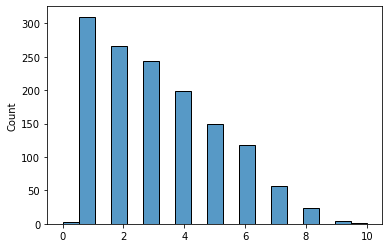

In [39]:
plot_N(ppo_result)

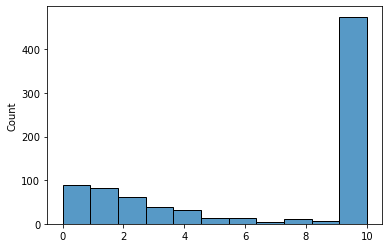

In [40]:
plot_N(topN_result)

Plot the number of MS1 and MS2 scans over time

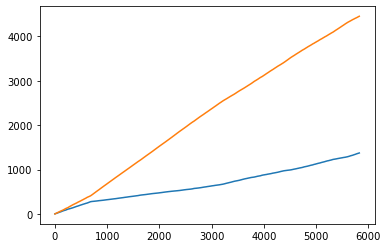

In [41]:
ppo_ms1, ppo_ms2 = plot_ms1_ms2_counts(ppo_result)

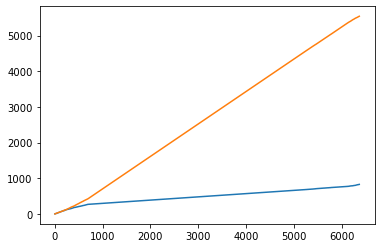

In [42]:
topN_ms1, topN_ms2 = plot_ms1_ms2_counts(topN_result)

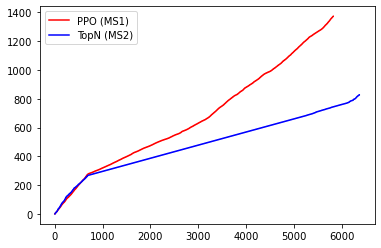

In [43]:
plt.plot(ppo_ms1, 'r-', label='PPO (MS1)')
plt.plot(topN_ms1, 'b-', label='TopN (MS2)')
# plt.plot(ppo_ms2, 'r--', label='PPO (MS2)')
# plt.plot(topN_ms2, 'b--', label='TopN (MS2)')
plt.legend()

Plot a histogram of all actions.

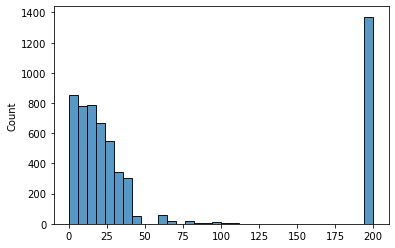

In [44]:
plot_action_hist(ppo_result)

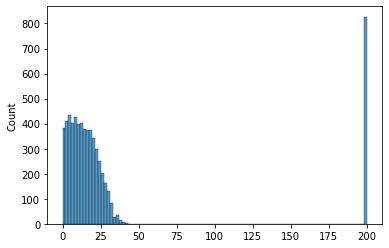

In [45]:
plot_action_hist(topN_result)

Plot a histogram of MS2-actions only

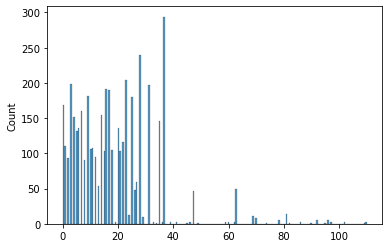

In [46]:
plot_action_hist(ppo_result, ms2_only=True, bins=199)

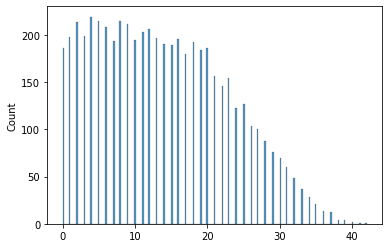

In [47]:
plot_action_hist(topN_result, ms2_only=True, bins=199)

Show the first few actions

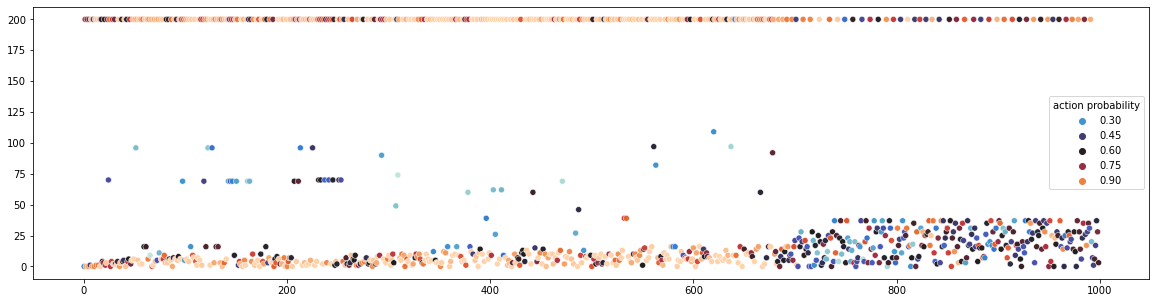

In [48]:
plot_action_probs(ppo_result, limit, max_peaks)

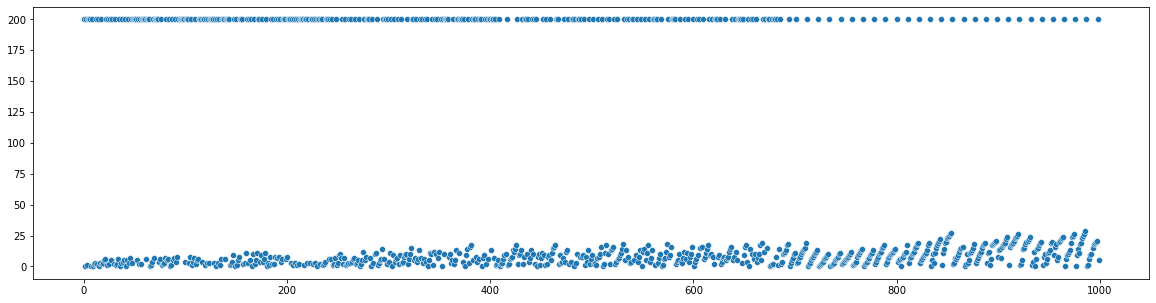

In [49]:
plot_action_probs(topN_result, limit, max_peaks)

Plot rewards coloured by action probabilities

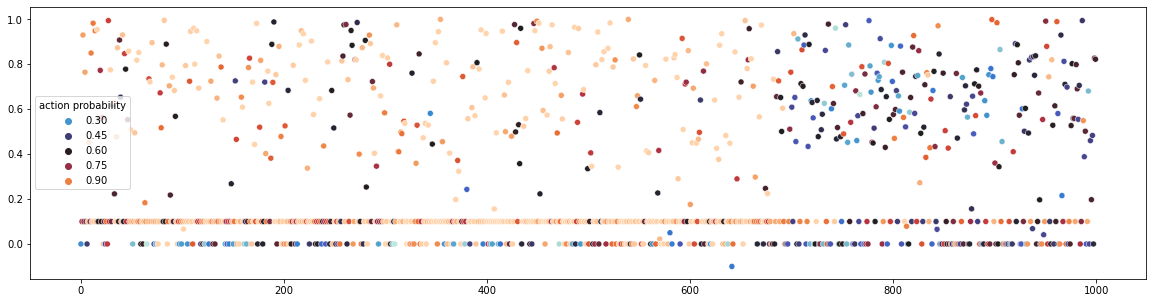

In [50]:
plot_reward_probs(ppo_result, limit, max_peaks)

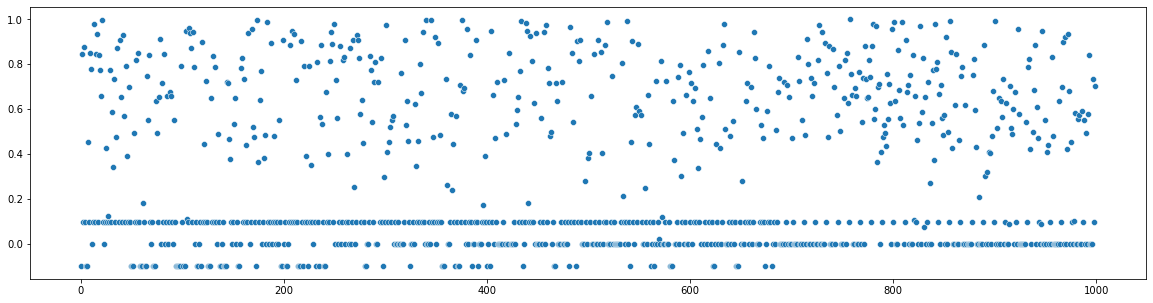

In [51]:
plot_reward_probs(topN_result, limit, max_peaks)